In [1]:
## Justin Ogle
## EE 258
## Final Project Code CNN
## Final Code

import numpy as np
import pandas as pd
from pathlib import Path
import os.path
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras import Model
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import (TextArea, DrawingArea, OffsetImage,AnnotationBbox)
import matplotlib.patches as mpatches
import seaborn as sns
import random
import shutil
from shutil import copyfile
# Loop through files in the specified directory
for dirname, _, filenames in os.walk('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data'):
    for filename in filenames:
       (os.path.join(dirname, filename))

In [2]:
# Define directories and file paths
train_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/train')
train_filepaths = list(train_dir.glob(r'**/*.jpg'))
valid_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/validation')
valid_filepaths = list(valid_dir.glob(r'**/*.jpg'))
test_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/test')
test_filepaths = list(test_dir.glob(r'**/*.jpg'))
# Define constants
num_classes = 51

In [3]:
# Data augmentation configurations
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [4]:
# Generate data flows for training, testing, and validation
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode="categorical",
    shuffle=False
)

validation_generator = validation_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=128,
    class_mode="categorical"
)

Found 4013 images belonging to 51 classes.
Found 474 images belonging to 51 classes.
Found 456 images belonging to 51 classes.


In [5]:
# Create the base model using MobileNetV2
from tensorflow.keras.applications import MobileNetV2
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
# Set base model layers as non-trainable
for layer in base_model.layers:
    layer.trainable = False

In [6]:
# Build CNN Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model
# Define the input and output layers for the CNN model
# base_model is the pre-trained MobileNetV2 model
x = base_model.output
# Add a GlobalAveragePooling2D layer to reduce spatial dimensions and flatten the output
x = GlobalAveragePooling2D()(x)
# Add a Dense layer with 1024 units and ReLU activation function
x = Dense(1024, activation="relu")(x)
# Add the final Dense layer with num_classes units and softmax activation for classification
predictions = Dense(num_classes, activation="softmax")(x)
# Create the final CNN model by specifying inputs and outputs
model = Model(inputs=base_model.input, outputs=predictions)

In [7]:
# Compile the model with Adam optimizer, categorical cross-entropy loss, and accuracy metric
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [8]:
# Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=30
)

C:\Users\jabuu\anaconda3\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/30
31/31 [==============================] - 405s 13s/step - loss: 1.8511 - accuracy: 0.5246 - val_loss: 0.6223 - val_accuracy: 0.8047
Epoch 2/30
31/31 [==============================] - 304s 10s/step - loss: 0.7013 - accuracy: 0.7879 - val_loss: 0.3251 - val_accuracy: 0.9141
Epoch 3/30
31/31 [==============================] - 266s 9s/step - loss: 0.4468 - accuracy: 0.8615 - val_loss: 0.2661 - val_accuracy: 0.9297
Epoch 4/30
31/31 [==============================] - 267s 9s/step - loss: 0.3283 - accuracy: 0.9001 - val_loss: 0.2793 - val_accuracy: 0.9271
Epoch 5/30
31/31 [==============================] - 268s 9s/step - loss: 0.2385 - accuracy: 0.9313 - val_loss: 0.2100 - val_accuracy: 0.9505
Epoch 6/30
31/31 [==============================] - 273s 9s/step - loss: 0.1912 - accuracy: 0.9439 - val_loss: 0.1863 - val_accuracy: 0.9583
Epoch 7/30
31/31 [==============================] - 283s 9s/step - loss: 0.1442 - accuracy: 0.9612 - val_loss: 0.1830 - val_accuracy: 0.9557
Epoch 8/30


In [9]:
# Create a DataFrame to store training history
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,accuracy,val_loss,val_accuracy
0,1.851102,0.524582,0.622334,0.804688
1,0.701347,0.787902,0.325149,0.914062
2,0.446820,0.861519,0.266145,0.929688
3,0.328269,0.900129,0.279262,0.927083
4,0.238487,0.931274,0.210018,0.950521


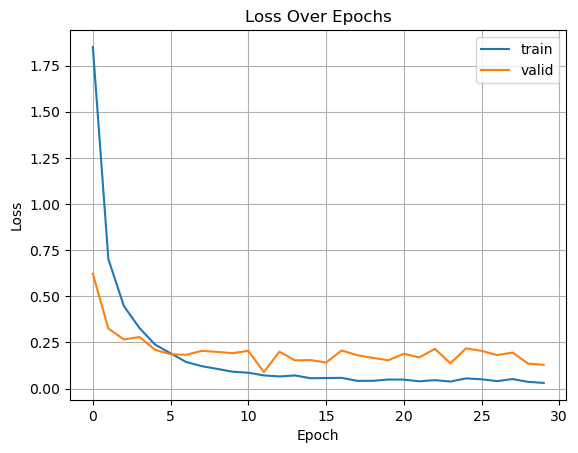

In [10]:
# Plot the loss history
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["train", "valid"])
plt.title("Loss Over Epochs")
plt.grid(True)  # Add a grid
plt.show()

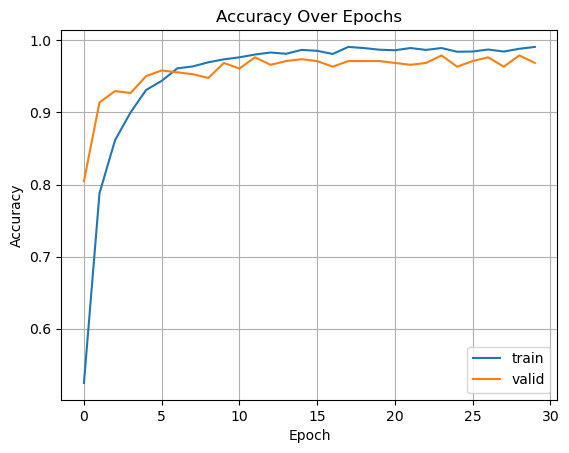

In [11]:
# Plot the accuracy history
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["train", "valid"])
plt.title("Accuracy Over Epochs")
plt.grid(True)  # Add a grid
plt.show()

In [12]:
# Make predictions on the test data
preds = model.predict(test_generator)

4/4 [==============================] - 49s 13s/step


In [13]:
y_pred = np.argmax(preds, axis=1)

In [14]:
# Print class indices
for k, v in test_generator.class_indices.items():
    print(v, ":", k)

0 : apple
1 : banana
2 : beetroot
3 : bell pepper
4 : blackberry
5 : blueberry
6 : cabbage
7 : capsicum
8 : carrot
9 : cauliflower
10 : cherry
11 : chilli pepper
12 : corn
13 : cucumber
14 : dragonfruit
15 : eggplant
16 : garlic
17 : ginger
18 : grapes
19 : honeydew
20 : jackfruit
21 : jalepeno
22 : kiwi
23 : lemon
24 : lettuce
25 : mango
26 : mushroom
27 : olive
28 : onion
29 : orange
30 : papaya
31 : paprika
32 : parsnip
33 : pear
34 : peas
35 : pineapple
36 : plum
37 : pomegranate
38 : potato
39 : raddish
40 : raspberry
41 : rutabaga
42 : soy beans
43 : spinach
44 : strawberry
45 : sweetcorn
46 : sweetpotato
47 : tomato
48 : turnip
49 : unknown
50 : watermelon


In [15]:
# Define a mapping of class indices to class names
pred_classes = {
    0 : "apple",
    1 : "banana",
    2 : "beetroot",
    3 : "bell pepper",
    4 : "blackberry",
    5 : "blueberry",
    6 : "cabbage",
    7 : "capsicum",
    8 : "carrot",
    9 : "cauliflower",
    10 : "cherry",
    11 : "chilli pepper",
    12 : "corn",
    13 : "cucumber",
    14 : "dragonfruit",
    15 : "eggplant",
    16 : "garlic",
    17 : "ginger",
    18 : "grapes",
    19 : "jalepeno",
    20 : "jackfruit",
    21 : "jalepeno",
    22 : "kiwi",
    23 : "lemon",
    24 : "lettuce",
    25 : "mango",
    26 : "mushroom",
    27 : "olive",
    28 : "onion",
    29 : "orange",
    30 : "papaya",
    31 : "paprika",
    32 : "parsnip",
    33 : "pear",
    34 : "peas",
    35 : "pineapple",
    36 : "plum",
    37 : "pomegranate",
    38 : "potato",
    39 : "raddish",
    40 : "raspberry",
    41 : "rutabaga",
    42 : "soy beans",
    43 : "spinach",
    44 : "strawberry",
    45 : "sweetcorn",
    46 : "sweetpotato",
    47 : "tomato",
    48 : "turnip",
    49 : "unknown",
    50 : "watermelon"
}

In [16]:
# Map predicted indices to class names
y_pred = list(map(lambda x: pred_classes[x], y_pred))
y_test = list(map(lambda x: pred_classes[x], test_generator.classes))

In [17]:
# Generate a classification report
from sklearn.metrics import classification_report
print(classification_report(y_pred, y_test))

               precision    recall  f1-score   support

        apple       0.80      1.00      0.89         8
       banana       0.78      1.00      0.88         7
     beetroot       1.00      1.00      1.00        10
  bell pepper       1.00      0.77      0.87        13
   blackberry       1.00      1.00      1.00         9
    blueberry       1.00      1.00      1.00         6
      cabbage       1.00      1.00      1.00        10
     capsicum       0.60      1.00      0.75         6
       carrot       0.90      1.00      0.95         9
  cauliflower       1.00      1.00      1.00        10
       cherry       1.00      1.00      1.00         9
chilli pepper       1.00      0.91      0.95        11
         corn       0.90      0.82      0.86        11
     cucumber       1.00      1.00      1.00        10
  dragonfruit       1.00      1.00      1.00         3
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       gi

In [18]:
# Define a directory for additional image testing
imgTest_dir = Path('Desktop/Grad School Homework/EE 258/EE 258 Final Project/Final Project Data/imgTest')
imgTest_filepaths = list(imgTest_dir.glob(r'**/*.jpg'))
# Prepare data augmentation for image testing
imgTest_datagen = ImageDataGenerator(
    rescale=1./255
)
imgTest_generator = imgTest_datagen.flow_from_directory(
    imgTest_dir,
    target_size=(224, 224),
    batch_size=1,
    class_mode="categorical",
    shuffle=False
)
# Make predictions on the additional test images
preds = model.predict(imgTest_generator)
y_pred = np.argmax(preds, axis=1)
# Map predicted indices to class names for additional test images
y_pred = list(map(lambda x: pred_classes[x], y_pred))
print("")
print("CNN Final Results")
print("")
print("What are these images? ",y_pred)

# Classify the results into vegetables, fruits, and unknown categories
vegetables = []
fruits = []
unknown = []

for filename in y_pred:
    if any(keyword in filename for keyword in ["beetroot", "bell pepper", "cabbage", "capsicum", "carrot", "cauliflower", "chilli pepper", "corn", "cucumber", "eggplant", "garlic", "ginger", "jalapeno", "lettuce", "mushroom", "olives", "onion", "paprika", "parsnip", "peas", "potato", "radish", "rutabaga", "soybeans", "spinach", "sweetpotato", "sweetcorn", "tomato", "turnip"]):
        vegetables.append(filename)
    elif any(keyword in filename for keyword in ["apple", "banana", "blackberry", "blueberry", "cherry", "dragonfruit", "grapes", "honeydew", "jackfruit", "kiwi", "lemon", "mango", "orange", "papaya", "pear", "pineapple", "pomegranate", "plum", "raspberry", "strawberry", "watermelon"]):
        fruits.append(filename)
    else:
        unknown.append(filename)
print("")
print("Which of these are vegetables, fruits, or not a type of produce?")
print("")
print("Fruits:", fruits)
print("")
print("Vegetables:", vegetables)
print("")
print ("Not a type of produce:", unknown)

Found 47 images belonging to 1 classes.
 4/47 [=>............................] - ETA: 3s

C:\Users\jabuu\anaconda3\lib\site-packages\PIL\Image.py:996: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


47/47 [==============================] - 3s 57ms/step

CNN Final Results

What are these images?  ['watermelon', 'cherry', 'unknown', 'apple', 'orange', 'beetroot', 'raspberry', 'sweetpotato', 'cauliflower', 'cabbage', 'soy beans', 'corn', 'jackfruit', 'chilli pepper', 'papaya', 'bell pepper', 'cucumber', 'carrot', 'cherry', 'ginger', 'jalepeno', 'peas', 'grapes', 'garlic', 'orange', 'kiwi', 'raddish', 'plum', 'potato', 'eggplant', 'strawberry', 'paprika', 'mango', 'onion', 'lettuce', 'olive', 'capsicum', 'rutabaga', 'blackberry', 'banana', 'pomegranate', 'parsnip', 'lemon', 'strawberry', 'blackberry', 'pear', 'mushroom']

Which of these are vegetables, fruits, or not a type of produce?

Fruits: ['watermelon', 'cherry', 'apple', 'orange', 'raspberry', 'jackfruit', 'papaya', 'cherry', 'grapes', 'orange', 'kiwi', 'plum', 'strawberry', 'mango', 'blackberry', 'banana', 'pomegranate', 'lemon', 'strawberry', 'blackberry', 'pear']

Vegetables: ['beetroot', 'sweetpotato', 'cauliflower', 'cabba